## **1. EDA**

&emsp;a) Imports

In [66]:
import pandas as pd
import re
import seaborn as sns
from scipy.stats import zscore
import matplotlib.pyplot as plt


&emsp;b) Preprocessing

In [67]:
def write_sents(file):
    print('Removing comments..')
    with open(file, 'r', encoding='utf-8') as f:
        sentences = []
        id = ""
        time = ""
        for line in f:
            if line.startswith('# prompt:'):
                continue

            elif line.startswith('# '):
                cols = line.split(' ')
                cols = [col for col in cols if col != '']
                id = cols[1][5:] # prefixed with user:
                time = cols[-1][5:].rstrip() # prefixed with time:

            elif line != '\n':
                cols = line.split(' ')
                cols = [col for col in cols if col != '']
                cols[0] = cols[0][:-2]

                line = id + '\t' + '\t'.join(cols[:6]) + '\t' + time + '\t' + cols[-1]

                sentences.append(line)
        f.close()

    print('Writing sentences...')
    print(sentences[-1])
    file = f"{file.split('.')[0]}_readable_{file.split('.')[-1]}.txt"

    with open(file, 'w', encoding='utf-8') as f:
        for sentence in sentences:
            f.write(sentence)

In [68]:
write_sents('data/fr_en.slam.20190204.train')

Removing comments..
Writing sentences...
GIYQ1bA5	Pw8nO+in02	homme	NOUN	Gender=Masc|Number=Sing|fPOS=NOUN++	ROOT	0	3	0



&emsp;c) Explore Data

In [69]:
df = pd.read_csv('data/fr_en_readable_train.txt', sep='\t', header=None, names=['user_id', 'sent_id', 'token', 'POS', 'Morpho-Syntactic_Features', 'Dependency-Relation', 'Dependancy-Head', 'time', 'p_recall'])
rows = len(df)
df.head(6)


,user_id,sent_id,token,POS,Morpho-Syntactic_Features,Dependency-Relation,Dependancy-Head,time,p_recall
0,YjS/mQOx,8XTyQUAl01,Le,DET,Definite=Def|Gender=Masc|Number=Sing|fPOS=DET++,det,2,14.0,0
1,YjS/mQOx,8XTyQUAl01,garçon,NOUN,Gender=Masc|Number=Sing|fPOS=NOUN++,ROOT,0,14.0,0
2,YjS/mQOx,8XTyQUAl02,Je,PRON,Number=Sing|Person=1|PronType=Prs|fPOS=PRON++,nsubj,4,14.0,0
3,YjS/mQOx,8XTyQUAl02,suis,VERB,Mood=Ind|Number=Sing|Person=1|Tense=Pres|VerbF...,cop,4,14.0,0
4,YjS/mQOx,8XTyQUAl02,une,DET,Definite=Ind|Gender=Fem|Number=Sing|PronType=D...,det,4,14.0,0
5,YjS/mQOx,8XTyQUAl02,femme,NOUN,Gender=Fem|Number=Sing|fPOS=NOUN++,ROOT,0,14.0,0


In [70]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 926646 entries, 0 to 926645
Data columns (total 9 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   user_id                    926646 non-null  str    
 1   sent_id                    926646 non-null  str    
 2   token                      926646 non-null  str    
 3   POS                        926646 non-null  str    
 4   Morpho-Syntactic_Features  926646 non-null  str    
 5   Dependency-Relation        926646 non-null  str    
 6   Dependancy-Head            926646 non-null  int64  
 7   time                       868207 non-null  float64
 8   p_recall                   926646 non-null  int64  
dtypes: float64(1), int64(2), str(6)
memory usage: 127.2 MB


In [71]:
df.describe()

,Dependancy-Head,time,p_recall
count,926646.000000,868207.000000,926646.000000
mean,1.907721,29.003748,0.162266
std,1.718631,723.370040,0.368695
min,0.000000,0.000000,0.000000
25%,0.000000,5.000000,0.000000
50%,2.000000,10.000000,0.000000
75%,3.000000,17.000000,0.000000
max,15.000000,94821.000000,1.000000


&emsp;d) Analyze Outliers and Determine Outlier Boundaries

In [72]:
# Analyze outliers in time column
descending_time = df.sort_values(by='time', ascending=False).iloc[9267:]
# descending_time['z_score_time'] = zscore(descending_time['time'])
# descending_time = descending_time[descending_time['z_score_time'] < 3]
descending_time.head(10)

,user_id,sent_id,token,POS,Morpho-Syntactic_Features,Dependency-Relation,Dependancy-Head,time,p_recall
572649,Uc0+Yq5G,haatOHtE02,confiture,NOUN,Gender=Fem|Number=Sing|fPOS=NOUN++,ROOT,0,76.0,1
565563,si/zsQbs,ZYe13aMR01,calme,ADJ,Gender=Masc|Number=Sing|fPOS=ADJ++,ROOT,0,76.0,0
506794,Aicaofcm,K8LHf+Sc01,possède,VERB,Mood=Ind|Number=Sing|Person=3|Tense=Pres|VerbF...,ROOT,0,76.0,1
506795,Aicaofcm,K8LHf+Sc01,un,DET,Definite=Ind|Gender=Masc|Number=Sing|PronType=...,det,4,76.0,0
201878,7Tdec8Qn,r9fU4nXO03,le,DET,Definite=Def|Gender=Masc|Number=Sing|fPOS=DET++,det,5,76.0,0
910135,GPJJBZQ6,QN+8XUhp01,œuf,NOUN,Gender=Masc|Number=Sing|fPOS=NOUN++,ROOT,0,76.0,0
910134,GPJJBZQ6,QN+8XUhp01,Un,DET,Definite=Ind|Gender=Masc|Number=Sing|PronType=...,det,2,76.0,0
569549,VFme/QtN,Ze6hV06Z03,vôtre,VERB,Gender=Fem|Number=Sing|fPOS=NOUN++,ROOT,0,76.0,1
506796,Aicaofcm,K8LHf+Sc01,cochon,NOUN,Gender=Masc|Number=Sing|fPOS=NOUN++,dobj,2,76.0,0
820607,lPlNI1Ar,MlIv05dE06,sienne,NOUN,Gender=Fem|Number=Sing|fPOS=NOUN++,dobj,3,76.0,1


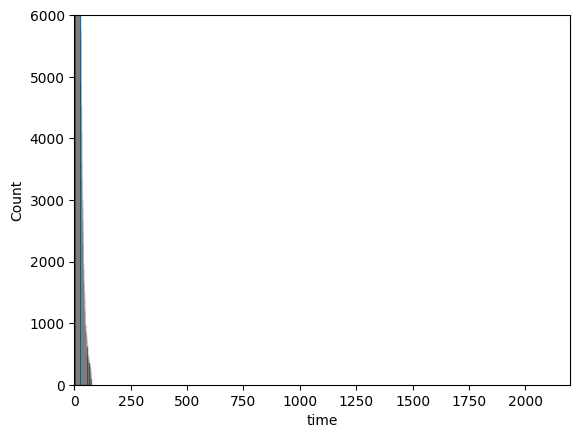

In [73]:
sns.histplot(data=descending_time, x='time')
plt.ylim(0, 6000)
plt.xlim(0, 2200)
plt.show()

&emsp;e) Handles Missing Values and Duplicates

In [74]:
# missing values and duplicates
df = df.drop_duplicates()
print(df.isnull().sum())
print(f"Number of duplicate rows: {df.duplicated().sum()}")

user_id                          0
sent_id                          0
token                            0
POS                              0
Morpho-Syntactic_Features        0
Dependency-Relation              0
Dependancy-Head                  0
time                         58437
p_recall                         0
dtype: int64
Number of duplicate rows: 0


In [75]:
# rows_missing_time = df[df['time'].isnull()]
# rows_missing_time.head(5)

# NsrjY0A = df[(
#     df['ID'] == 'Nsr+jY0A')
#     & (df['token'] == "I eat.")]
# NsrjY0A.head(100)
"""
Here I identified that some excercises have null values for time and with this in mind, I will be removing those rows. They do not serve 
a purpose as the point of this data is to analyze the relationship between recall time and recall accuracy, given various features.
Given the goal, all the following columns are relevant to the analysis, but the time column is of great importance.
"""
df = df.dropna(subset=['time'])
print(f"Number of missing values is now:\n{df.isnull().sum()}")


Number of missing values is now:
user_id                      0
sent_id                      0
token                        0
POS                          0
Morpho-Syntactic_Features    0
Dependency-Relation          0
Dependancy-Head              0
time                         0
p_recall                     0
dtype: int64


&emsp;f) Examine Trends

In [76]:
# Analyze exercises by user_id and sent_id - focusing on recall time and recall accuracy
exercises = (df.groupby('sent_id').agg(
    user_id=('user_id', 'first'),
    sent_id=('sent_id', 'first'),
    time=('time', 'first'),
    recall_avg=('p_recall', 'mean'),
))

NsrjY0A_exercises = exercises[exercises['user_id'] == 'Nsr+jY0A']
NsrjY0A_exercises.describe()

,time,recall_avg
count,562.000000,562.000000
mean,14.423488,0.342836
std,79.494966,0.329998
min,1.000000,0.000000
25%,6.000000,0.000000
50%,9.000000,0.333333
75%,15.000000,0.500000
max,1888.000000,1.000000


<function matplotlib.pyplot.show(close=None, block=None)>

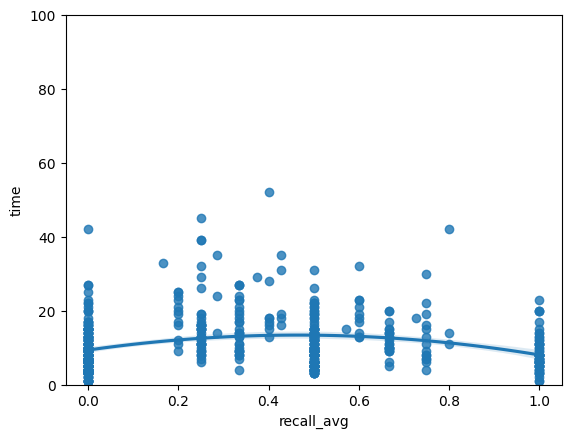

In [77]:
sns.regplot(data=NsrjY0A_exercises[NsrjY0A_exercises['time'] < 500], y='time', x='recall_avg', order=2)
plt.ylim(0, 100)
plt.show

In [78]:
# Compare POS tags with recall time and recall accuracy
pos_time_recall = descending_time.groupby('POS').agg(
    avg_time=('time', 'mean'),
    avg_recall=('p_recall', 'mean'),
    count=('POS', 'count')
).reset_index()
pos_time_recall.head(100)

,POS,avg_time,avg_recall,count
0,ADJ,12.420503,0.186754,68068
1,ADP,14.176269,0.404407,15430
2,ADV,12.321834,0.184679,27361
3,AUX,13.493194,0.179870,5832
4,CONJ,17.103994,0.104332,10965
5,DET,13.021698,0.171502,186593
6,INTJ,10.743741,0.055400,17545
7,NOUN,12.897584,0.150200,210047
8,NUM,17.047969,0.135970,6700
9,PART,17.290452,0.195736,1032


In [79]:
# Compare token with recall time and recall accuracy
token_time_recall = descending_time.groupby('token').agg(
    avg_time=('time', 'mean'),
    avg_recall=('p_recall', 'mean'),
    count=('token', 'count')
).reset_index().sort_values(by='avg_time', ascending=False)
token_time_recall.head(10)

,token,avg_time,avg_recall,count
30,Avons,71.0,1.0,1
1632,propriété,71.0,0.5,2
1791,saint,67.0,1.0,1
727,couvertures,63.0,0.0,1
1631,propriétaire,63.0,0.0,1
1580,posons,63.0,1.0,1
383,appartement,62.0,0.0,2
410,arrives,60.5,0.5,2
1898,stratégie,60.0,0.0,1
316,affirment,59.0,1.0,1


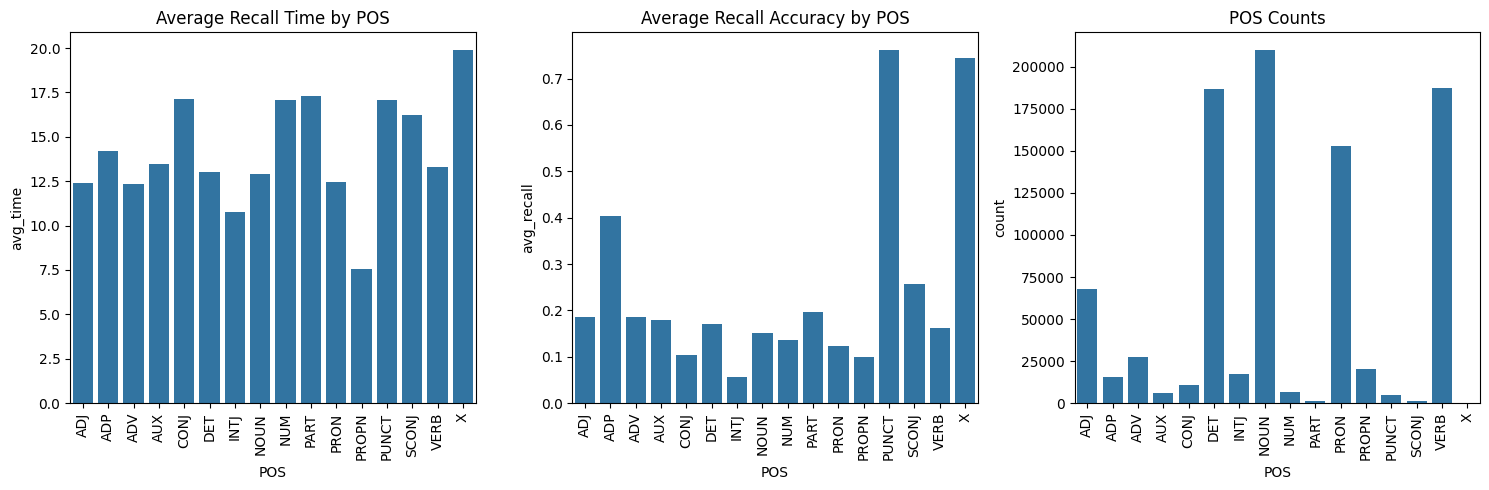

In [80]:
fig, axs = plt.subplots(ncols=3, figsize=(15, 5))
"""
have to rememeber that average time is not the most accurate as it specifically looks at
the time taken on whole question so this is better understood as average time taken on
questions with a specific POS tag
"""
sns.barplot(data=pos_time_recall, x='POS', y='avg_time', ax=axs[0])
axs[0].set_title('Average Recall Time by POS')
axs[0].tick_params(axis='x', rotation=90)

sns.barplot(data=pos_time_recall, x='POS', y='avg_recall', ax=axs[1])
axs[1].set_title('Average Recall Accuracy by POS')
axs[1].tick_params(axis='x', rotation=90)

sns.barplot(data=pos_time_recall, x='POS', y='count', ax=axs[2])
axs[2].set_title('POS Counts')
axs[2].tick_params(axis='x', rotation=90)

plt.tight_layout()
plt.show()

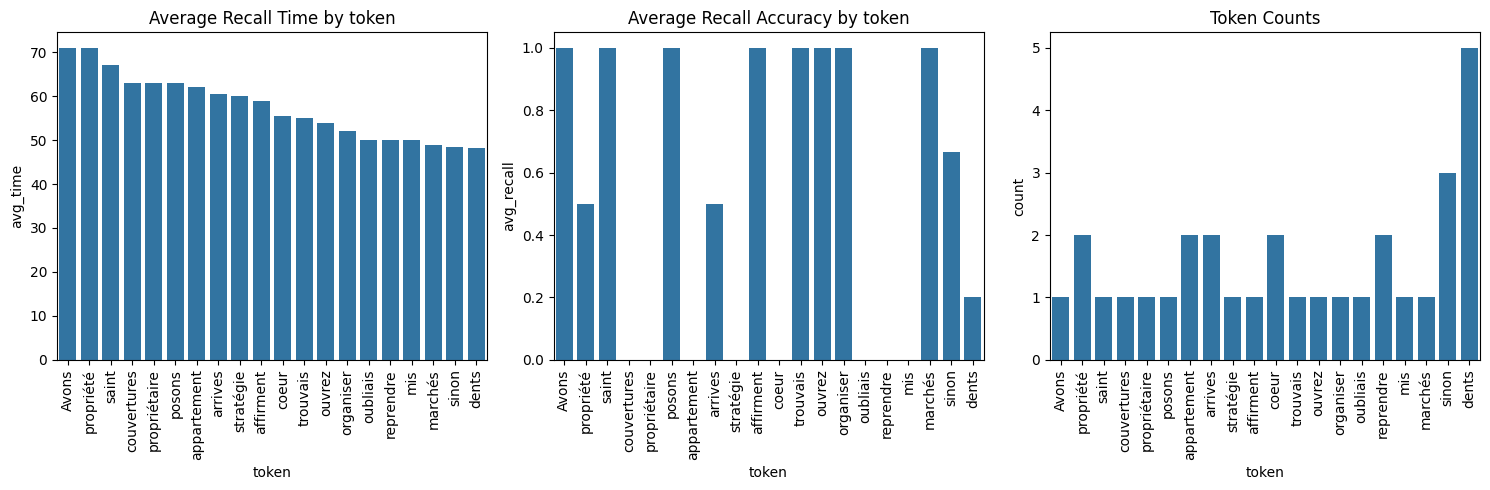

In [81]:
token_time_recall_20 = token_time_recall.head(20)
fig, axs = plt.subplots(ncols=3, figsize=(15, 5))
"""
What im noticing is that these are very low frequency tokens, which makes sense as they have a high average recall time. 
It suggests that the user is taking a long time to recall these tokens, but it may not be because they are difficult but rather because they are less familiar
It could also relate to less common verb forms, words heavy on accents, etc. but this is just a theory.
"""
sns.barplot(data=token_time_recall_20, x='token', y='avg_time', ax=axs[0])
axs[0].set_title('Average Recall Time by token')
axs[0].tick_params(axis='x', rotation=90)

sns.barplot(data=token_time_recall_20, x='token', y='avg_recall', ax=axs[1])
axs[1].set_title('Average Recall Accuracy by token')
axs[1].tick_params(axis='x', rotation=90)

sns.barplot(data=token_time_recall_20, x='token', y='count', ax=axs[2])
axs[2].set_title('Token Counts')
axs[2].tick_params(axis='x', rotation=90)

plt.tight_layout()
plt.show()

In [82]:
check_x = df[df['POS'] == 'X']
check_x.head(10)

,user_id,sent_id,token,POS,Morpho-Syntactic_Features,Dependency-Relation,Dependancy-Head,time,p_recall
11913,9anH9K01,kaH7CVw+05,vas,X,Gender=Masc|Number=Plur|fPOS=NOUN++,appos,2,43.0,1
14316,7jY3FNkf,x1fgyypt01,t,X,fPOS=X++,dobj,2,32.0,1
14329,7jY3FNkf,x1fgyypt05,t,X,fPOS=X++,conj,2,35.0,1
14338,7jY3FNkf,x1fgyypt07,t,X,fPOS=X++,conj,2,17.0,1
15967,7jY3FNkf,LagRGhCv04,t,X,fPOS=X++,dobj,2,15.0,0
15976,7jY3FNkf,LagRGhCv06,t,X,fPOS=X++,conj,2,26.0,1
16176,7jY3FNkf,vvv1/AeK06,Tu,X,Definite=Def|Gender=Masc|Number=Sing|fPOS=DET++,ROOT,0,16.0,0
16177,7jY3FNkf,vvv1/AeK06,as,X,Gender=Masc|Number=Sing|fPOS=NOUN++,compound,1,16.0,0
29674,ZU+Pcbjs,WCrGZ1G903,t,X,fPOS=X++,conj,2,25.0,1
31943,ZU+Pcbjs,1ZXvaw9J02,t,X,fPOS=X++,dobj,2,11.0,0


&emsp;g) Export Cleaned Data

In [83]:
df = df[df['time'] < 300] # remove outliers, specifically those above 2 mins
# df.head(5)
print(f"There are now {len(df)} out of {rows} data points after removing outliers, duplicates, and missing values.")
df.to_csv('data/fr_en_cleaned_train.csv', index=False)

There are now 866133 out of 926646 data points after removing outliers, duplicates, and missing values.


In [84]:
# Questions & Notes
# 1. What is the trend of recall time to ratio of recall_accuracy?
# Where is time null?
# why is there such a large max time value? Is it an outlier? What is the distribution of time values?
# def an outlier but im not sure where to cut it off. 5 hours doesnt make sense, but does 20 mins (3 z-scores from the mean)?
# maybe just to move on i can remove row with time > 2 mins - slightly arbitrary but feels reasonable and it will allow me to move forward with the analysis and i can always come back to this question later 
# the thing is these are only questions and not full excercises so it makes less sense for them to take a long time. I dont want to include example where the user got distracted and came back.

# what is this X category in POS? It appears rarely so it may be worth looking into what these examples are and if they should be removed. It could be a data error or it could be a specific type of token that is not being categorized correctly.
  # ANS: the X tag is a universal placeholder used for "other" - think "t" in "est-t-il" - things that function out side normal sentence grammar

# Punct trend is interesting because it has a high average recall time and low average recall accuracy. And specifically it refers to the utilization of
# "-" in french seen in some words or inversion. As the goal here is to determine ranking of flashcards perhaps this suggest compound words will pose more difficulty.


